In [1]:
import os
import pandas as pd
import re
import numpy as np
import GEO_to_XYcenter as xysar
import matplotlib.pyplot as plt
import xarray as xr

In [3]:
sargeo_modif_df = pd.read_csv("excels/SARGEO_modifiee.csv")   #chemin vers le csv du sargeo modifiée (liée avec le listing du sar)
sargeo_df = pd.read_csv("excels/SARGEO_cyclones.csv")                   #chemin vers le csv du sargeo
sar_list_df = pd.read_csv("excels/listing_sar.csv")           #chemin vers le csv du listing sar
sargeo_modif_df.fillna(0, inplace=True)
sargeo_modif_df.head(1)

,cyclone,canal,fichier,lat_centre,lon_centre,sar_acquisition_time,inter_list_sar,sar_file_path,sar_xy
0,al102019,IRWIN,s1a-iw-owi-cm-20190920t221952-20190920t222132-...,19.548832,298.289185,"2019-09-20T22:19:52,000",s1a-iw-owi-cm-20190920t221952-20190920t222132-...,0,0


In [4]:
sargeo_modif_df[sargeo_modif_df[sargeo_modif_df.columns[-1]]==0].head(2)

,cyclone,canal,fichier,lat_centre,lon_centre,sar_acquisition_time,inter_list_sar,sar_file_path,sar_xy
0,al102019,IRWIN,s1a-iw-owi-cm-20190920t221952-20190920t222132-...,19.548832,298.289185,"2019-09-20T22:19:52,000",s1a-iw-owi-cm-20190920t221952-20190920t222132-...,0,0
2,ep192022,IRWIN,s1a-iw-owi-cm-20221022t130700-20221022t130753-...,17.509211,253.851669,"2022-10-22T13:07:00,000",s1a-iw-owi-cm-20221022t130700-20221022t130753-...,0,0


In [5]:
sar_folder = "/scale/user/mtannaou/alternance/donnees_sar"      #chemin vers le dossier content les fichiers netcdf des SAR
output_dir = "/scale/user/mtannaou/alternance/donnees_sar_changes"         #chemin d output


# df_copy_sar_files = sargeo_modif_df[sargeo_modif_df[sargeo_modif_df.columns[-1]]!=0].copy()
# for file_path in df_copy_sar_files[df_copy_sar_files.columns[-1]]:
#     try:
#         xysar.convert_sar_to_xy(file_path, sargeo_modif_df, output_dir)
#     except Exception as e:
#         print(f"❌ Erreur pour {file}: {e}")

In [6]:
len(os.listdir("donnees_sar_changes"))

1243

In [122]:
i = 0
lim = True

/tmp/ipykernel_2927506/3268179728.py:9: FutureWarning: In a future version, xarray will not decode the variable 'time_diff' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds_geo = xr.open_dataset(sargeo_path+"/"+cyclone_name+"/IRWIN/"+geo_exemple_file_path)


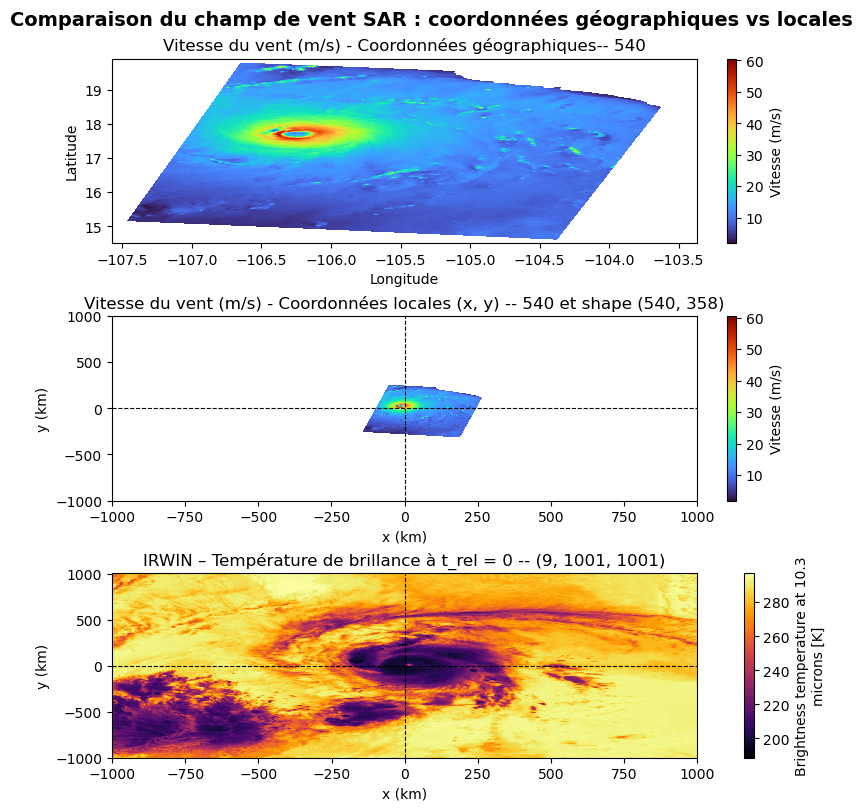

In [123]:
# Création de la figure
i = i+1
sargeo_path = "/scale/project/ifremer-isi-jumeaunumerique/SARGEO/prototype/v01r02/cyclobs"
row = sargeo_modif_df[sargeo_modif_df["sar_xy"] != 0].iloc[i]
sar_xy_exemple_file_path = row["sar_xy"]
cyclone_name = row["cyclone"]
geo_exemple_file_path = row["fichier"]
ds_sar_xy = xr.open_dataset(sar_xy_exemple_file_path)
ds_geo = xr.open_dataset(sargeo_path+"/"+cyclone_name+"/IRWIN/"+geo_exemple_file_path)
fig, axes = plt.subplots(3, 1, figsize=(8, 8), constrained_layout=True)

# --- 1️⃣ Coordonnées géographiques ---
# im00 = axes[0,0].pcolormesh(
#     ds_sar_xy["owiLon"], ds_sar_xy["owiLat"],
#     ds_sar_xy["owiWindDirection"], cmap="twilight", shading='auto'
# )
# axes[0,0].set_title("Direction du vent (°) - Coordonnées géographiques", fontsize=12)
# axes[0,0].set_xlabel("Longitude")
# axes[0,0].set_ylabel("Latitude")
# cbar00 = fig.colorbar(im00, ax=axes[0,0], orientation="vertical", pad=0.02)
# cbar00.set_label("° (par rapport au Nord)", rotation=90)

# --- 2️⃣ Coordonnées géographiques ---
im01 = axes[0].pcolormesh(
    ds_sar_xy["owiLon"], ds_sar_xy["owiLat"],
    ds_sar_xy["owiWindSpeed"], cmap="turbo", shading='auto'
)
axes[0].set_title(f"Vitesse du vent (m/s) - Coordonnées géographiques-- {len(ds_sar_xy["owiLon"])}", fontsize=12)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
cbar01 = fig.colorbar(im01, ax=axes[0], orientation="vertical", pad=0.02)
cbar01.set_label("Vitesse (m/s)", rotation=90)

# # --- 3️⃣ Coordonnées locales (centrées cyclone) ---
# im10 = axes[1,0].pcolormesh(
#     ds_sar_xy["x_sar"], ds_sar_xy["y_sar"],
#     ds_sar_xy["owiWindDirection"], cmap="twilight", shading='auto'
# )
# axes[1,0].set_title("Direction du vent (°) - Coordonnées locales (x, y)", fontsize=12)
# axes[1,0].set_xlabel("x (km)")
# axes[1,0].set_ylabel("y (km)")
# axes[1,0].axhline(0, color='white', linestyle='--', linewidth=0.8)
# axes[1,0].axvline(0, color='white', linestyle='--', linewidth=0.8)
# cbar10 = fig.colorbar(im10, ax=axes[1,0], orientation="vertical", pad=0.02)
# cbar10.set_label("° (par rapport au Nord)", rotation=90)

# --- 4️⃣ Coordonnées locales ---
im11 = axes[1].pcolormesh(
    ds_sar_xy["x_sar"], ds_sar_xy["y_sar"],
    ds_sar_xy["owiWindSpeed"], cmap="turbo", shading='auto'
)
axes[1].set_title(f"Vitesse du vent (m/s) - Coordonnées locales (x, y) -- {len(ds_sar_xy["owiWindSpeed"])} et shape {ds_sar_xy["owiWindSpeed"].shape}", fontsize=12)
axes[1].set_xlabel("x (km)")
axes[1].set_ylabel("y (km)")
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=0.8)
if lim : 
    axes[1].set_xlim(-1000,1000)
    axes[1].set_ylim(-1000,1000)
cbar11 = fig.colorbar(im11, ax=axes[1], orientation="vertical", pad=0.02)
cbar11.set_label("Vitesse (m/s)", rotation=90)

#image GEO 
ds_geo["IRWIN"].sel(t_rel=0).plot.imshow(cmap='inferno', ax=axes[2])
axes[2].set_title(f"IRWIN – Température de brillance à t_rel = 0 -- {ds_geo["IRWIN"].shape}")
axes[2].set_xlabel("x (km)")
axes[2].set_ylabel("y (km)")
axes[2].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[2].axvline(0, color='black', linestyle='--', linewidth=0.8)

# --- Ajustement global ---
fig.suptitle("Comparaison du champ de vent SAR : coordonnées géographiques vs locales", fontsize=14, fontweight='bold')
plt.show()

In [76]:
for i,file in enumerate(sargeo_modif_df[sargeo_modif_df["sar_xy"] != 0]["sar_xy"]) : 
    
    if i == 20 :
        break

    ds_cour = xr.open_dataset(file)
    print(len(ds_cour["owiWindSpeed"]))
    

514
540
831
528
350
503
512
510
504
699
507
503
503
503
505
506
504
506
425
518
